In [4]:
%load_ext autoreload
%autoreload 2

import investos as inv
import numpy as np
import pandas as pd


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Generate Data


In [5]:
%load_ext autoreload
%autoreload 2

from humbldata.core.standard_models.openbbapi.EquityPriceHistoricalQueryParams import (
    EquityPriceHistoricalQueryParams,
)
from humbldata.core.utils.openbb_api_client import OpenBBAPIClient
from humbldata.toolbox.toolbox_helpers import log_returns


async def prepare_actual_returns_for_investos(
    symbols: str = "SPY,XLU",
    start_date: str = "2018-06-20", # XLC starts on 2018-06-20
    end_date: str = "2025-10-10",
    provider: str = "yfinance",
    adjustment: str = "splits_and_dividends",
) -> pd.DataFrame:
    api_query_params = EquityPriceHistoricalQueryParams(
        symbol=symbols,
        start_date=start_date,
        end_date=end_date,
        provider=provider,
        adjustment=adjustment,
    )
    api_client = OpenBBAPIClient()
    api_response = await api_client.fetch_data(
        obb_path="equity.price.historical",
        api_query_params=api_query_params,
    )
    equity_historical_data = api_response.to_polars(collect=False)
    log_returns_df = log_returns(equity_historical_data, _column_name="close")
    log_returns_pd = log_returns_df.collect().to_pandas()

    # Handle single symbol case - add symbol column if it doesn't exist
    if "symbol" not in log_returns_pd.columns:
        single_symbol = symbols.strip()
        log_returns_pd["symbol"] = single_symbol

    log_returns_pivot = log_returns_pd.pivot(index="date", columns="symbol", values="log_returns")
    log_returns_pivot_clean = log_returns_pivot.dropna().copy()
    log_returns_pivot_clean.loc[:, "cash"] = 0.0
    return log_returns_pivot_clean

# Example usage in notebook:
actual_returns = await prepare_actual_returns_for_investos()
actual_returns


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


symbol,SPY,XLU,cash
date,,,
2018-06-21,-0.006289,0.003379,0.0
2018-06-22,0.001822,0.006920,0.0
2018-06-25,-0.013706,0.016416,0.0
2018-06-26,0.002211,0.001162,0.0
2018-06-27,-0.008319,0.004829,0.0
...,...,...,...
2025-10-06,0.003580,0.009626,0.0
2025-10-07,-0.003714,0.004557,0.0
2025-10-08,0.005945,0.006852,0.0


In [40]:
%load_ext autoreload
%autoreload 2

from humbldata.toolbox.toolbox_controller import Toolbox

toolbox = Toolbox(
    symbols=["XLE", "XLF", "XLU", "XLI", "XLK", "XLV", "XLY", "XLP", "XLRE", "XLB", "XLC"],
    start_date="2018-06-20",
    end_date="2025-10-10",
    membership="admin",
)
humbl_compass = await toolbox.fundamental.humbl_compass(
    country="united_states",
    z_score="3m",
    timegpt_enable=True,
    timegpt_h=3,
    timegpt_freq="1mo",
    timegpt_model="timegpt-1"
)
compass_metric = humbl_compass.to_pandas()
compass_metric

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,date_month_start,country,cpi,cpi_3m_delta,cli,cli_3m_delta,humbl_regime,is_forecast,cpi_zscore,cli_zscore
0,2018-03-01,United States,2.36,0.25,100.89,0.33,humblBOUNCE,False,1.01,0.92
1,2018-04-01,United States,2.46,0.39,100.92,0.22,humblBOUNCE,False,0.94,0.80
2,2018-05-01,United States,2.80,0.59,100.90,0.08,humblBOUNCE,False,1.13,-0.27
3,2018-06-01,United States,2.87,0.51,100.85,-0.04,humblBLOAT,False,0.73,-1.12
4,2018-07-01,United States,2.95,0.49,100.78,-0.14,humblBLOAT,False,1.02,-1.07
...,...,...,...,...,...,...,...,...,...,...
88,2025-07-01,United States,2.70,0.39,100.30,0.09,humblBOUNCE,False,0.67,1.02
89,2025-08-01,United States,2.92,0.56,100.33,0.13,humblBOUNCE,False,1.14,0.96
90,2025-09-01,united_states,2.82,0.15,100.41,0.17,humblBOUNCE,True,0.06,1.09
91,2025-10-01,united_states,2.79,0.08,100.46,0.17,humblBOUNCE,True,-0.82,0.92


In [22]:
%load_ext autoreload
%autoreload 2

from humbldata.portfolio.strategies.humbl_compass_simple_backtest import (
    HumblCompassSimpleBacktest,
)

# Run HumblCompassSimpleBacktest with existing actual_returns and monthly compass metric
backtest = HumblCompassSimpleBacktest(
    actual_returns=actual_returns,
    compass_metric=compass_metric,
    regime_alignment="tradable_asof",  # options: "tradable_asof" or "month_attribution"
    lag_months=2,
    carry_past_last_known=False,
    cash_column_name="cash",
)

result = backtest.generate_hisotrical_performance_backtest()
result.summary

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,symbol,metric,bucket,num_periods,num_instances,avg_instance_length,total_return,cumulative_return,annualized_return,annualized_excess_return,annualized_volatility,risk_over_cash_annualized,excess_risk_annualized,sharpe_ratio,information_ratio,average_drawdown,max_drawdown,portfolio_hit_rate,annual_turnover
0,SPY,humblCOMPASS,humblBLOAT,356.0,6.0,59.333333,0.015154,0.015154,0.010704,0.010704,0.189632,0.189632,0.189632,0.056144,0.056144,-0.050868,-0.243651,0.511236,None
1,SPY,humblCOMPASS,humblBOOM,290.0,4.0,72.500000,0.138602,0.138602,0.119400,0.119400,0.130460,0.130460,0.130460,0.864580,0.864580,-0.050319,-0.099743,0.548276,None
2,SPY,humblCOMPASS,humblBOUNCE,582.0,8.0,72.750000,0.321576,0.321576,0.128318,0.128318,0.250843,0.250843,0.250843,0.481289,0.481289,-0.098024,-0.337173,0.572165,None
3,SPY,humblCOMPASS,humblBUST,609.0,7.0,87.000000,0.735228,0.735228,0.256157,0.256157,0.172293,0.172293,0.172293,1.323664,1.323664,-0.062878,-0.192032,0.561576,None
4,XLU,humblCOMPASS,humblBLOAT,356.0,6.0,59.333333,0.075915,0.075915,0.053161,0.053161,0.168680,0.168680,0.168680,0.307065,0.307065,-0.056950,-0.157095,0.533708,None
5,XLU,humblCOMPASS,humblBOOM,290.0,4.0,72.500000,-0.055738,-0.055738,-0.048615,-0.048615,0.171463,0.171463,0.171463,-0.290654,-0.290654,-0.109192,-0.172578,0.510345,None
6,XLU,humblCOMPASS,humblBOUNCE,582.0,8.0,72.750000,0.534168,0.534168,0.203597,0.203597,0.275213,0.275213,0.275213,0.673349,0.673349,-0.096385,-0.360668,0.551546,None
7,XLU,humblCOMPASS,humblBUST,609.0,7.0,87.000000,0.447644,0.447644,0.165415,0.165415,0.170188,0.170188,0.170188,0.899460,0.899460,-0.058760,-0.114425,0.559934,None


## Trading Simulation
- tradeable_asof:

The most realistic trading behaviour. It simulates and lags the humblREGIME to match the publication lag. For exmaple, if we are making a trade and positioning today (Oct 14th 2025), the trade will be assigned to the humblREGIME as of Aug 2025 (2 months lag). This mimics us looking at the humblCOMPASS data on that day and seeing the Aug 2025 regime as the latest.

The fix is to generate a forecast time-series of the humblCOMPASS and use that to generate the trade list. We need to test its accuracy on out-of-sample data for prediciton and then trade that. 

In [23]:
from humbldata.core.standard_models.portfolio.strategies.regimes import (
    HumblCompassPositionLogic,
    HumblCompassPositionSideList,
)
from humbldata.portfolio.strategies.humbl_compass_simple_backtest import (
    HumblCompassSimpleBacktest,
)

logic = HumblCompassPositionLogic(
    humblBOOM=HumblCompassPositionSideList(long=["SPY"], short=[]),
    humblBOUNCE=HumblCompassPositionSideList(long=["XLU","SPY"], short=[]),
    # humblBLOAT=HumblCompassPositionSideList(long=["GLD","XLP","XLU"], short=["SPY","XLF","IWM"]),
    # humblBUST=HumblCompassPositionSideList(long=["XLU"], short=["SPY"]),
)
strat = HumblCompassSimpleBacktest(
    actual_returns=actual_returns,
    compass_metric=compass_metric,
    humbl_compass_position_logic=logic,
    allow_shorts=True,
    target_invested_fraction=1.0,
    regime_alignment="month_attribution",
)

In [24]:
from investos.portfolio.backtest_controller import BacktestController

backtest_controller = BacktestController(
  strategy=strat,
  start_date="2018-06-20",
  end_date="2025-10-10",
  aum=100000,
)




In [25]:
result = backtest_controller.generate_positions()

Generating historical portfolio trades and positions at 2025-10-15 11:48:18...


Done simulating at 2025-10-15 11:48:19.


In [26]:
result.summary

Initial timestamp                         2018-06-21 00:00:00
Final timestamp                           2025-10-10 00:00:00
Total portfolio return (%)                            122.84%
Annualized portfolio return (%)                        11.59%
Annualized excess portfolio return (%)                 11.59%
Annualized excess risk (%)                              8.67%
Information ratio (x)                                   1.34x
Annualized risk over risk-free (%)                      8.67%
Sharpe ratio (x)                                        1.34x
Max drawdown (%)                                       12.38%
Annual turnover (x)                                     2.23x
Portfolio hit rate (%)                                 28.27%


In [28]:
trades = result.trades
trades

symbol,SPY,XLU,cash
2018-06-21,0.000000,0.000000,-0.000000e+00
2018-06-22,0.000000,0.000000,-0.000000e+00
2018-06-25,0.000000,0.000000,-0.000000e+00
2018-06-26,0.000000,0.000000,-0.000000e+00
2018-06-27,0.000000,0.000000,-0.000000e+00
...,...,...,...
2025-10-06,633.167589,-633.167589,2.910383e-11
2025-10-07,333.264815,-333.264815,-0.000000e+00
2025-10-08,458.912319,-458.912319,-2.910383e-11
2025-10-09,50.305796,-50.305796,-0.000000e+00


<Axes: >

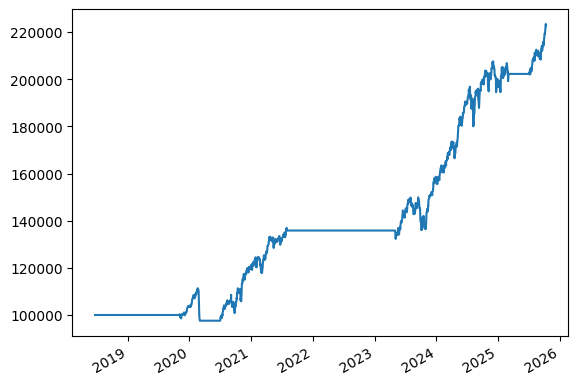

In [29]:
result.v.plot()

In [81]:
strat.metrics["humblCOMPASS"]

,SPY,XLU
date,,
2018-06-21,humblBLOAT,humblBLOAT
2018-06-22,humblBLOAT,humblBLOAT
2018-06-25,humblBLOAT,humblBLOAT
2018-06-26,humblBLOAT,humblBLOAT
2018-06-27,humblBLOAT,humblBLOAT
...,...,...
2025-10-06,None,None
2025-10-07,None,None
2025-10-08,None,None
